In [1]:
!pip install abnumber
!pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 77.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

from abnumber import Chain

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Projects/IGEM Summer 2026/Therapeutic Antibody Humanization Prediction /humanization_scores.csv")

print(df.shape)
df.head()

(23022, 5)


,sequence,label,species,length,humanization_score
0,SVKVSCKASGFTFSRSAVQWVRQARGQCLEWIGWIVVGSGNTNYAQ...,1,human,100,0.745
1,SVKVSCKASGFTFTSSAVQWVRQARGQRLEWIGWIVVGSDNTNYAQ...,1,human,107,0.995
2,SVKVSCKASGFTFTSSAVQWVRQARGQRLEWIGWIVVGSGNTNYAQ...,1,human,104,1.000
3,ASVKVSCKASGGTFSSYAISWVRQATGQGLEWMGWMNPNSGNTGYA...,1,human,112,1.000
4,ASVKVSCKASGYTFTSYDINWVRQATGQGLEWMGWMNPNSGNTGYA...,1,human,102,1.000


In [7]:
!pip install anarci

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.1 MB/s eta 0:00:00


In [8]:
seq = df.iloc[0]["sequence"]

chain = Chain(seq, scheme="imgt")

print("CDR1:", chain.cdr1_seq)
print("CDR2:", chain.cdr2_seq)
print("CDR3:", chain.cdr3_seq)

CDR1: GFTFSRSA
CDR2: IVVGSGNT
CDR3: AATLRSLESDYYLDL


In [9]:
def extract_regions(sequence):

    try:
        chain = Chain(sequence, scheme="imgt")

        return {
            "cdr1": str(chain.cdr1_seq),
            "cdr2": str(chain.cdr2_seq),
            "cdr3": str(chain.cdr3_seq),

            "fr1": str(chain.fr1_seq),
            "fr2": str(chain.fr2_seq),
            "fr3": str(chain.fr3_seq),
            "fr4": str(chain.fr4_seq)
        }

    except:
        return None

In [10]:
subset = df.sample(
    2000,
    random_state=42
).copy()

In [11]:
region_data = []

for seq in tqdm(subset["sequence"]):

    result = extract_regions(seq)

    region_data.append(result)

100%|██████████| 2000/2000 [01:10<00:00, 28.47it/s]


In [12]:
region_data = []

for seq in tqdm(subset["sequence"]):

    result = extract_regions(seq)

    region_data.append(result)

100%|██████████| 2000/2000 [01:04<00:00, 31.09it/s]


In [14]:
regions_df = pd.DataFrame([r for r in region_data if r is not None])

regions_df.head()

,cdr1,cdr2,cdr3,fr1,fr2,fr3,fr4
0,GFTFSRSA,IVVGSGNT,AATLRSLESDYYLDL,SVKVSCKAS,VQWVRQARGQCLEWIGW,NYAQKLQERVTITRDMSTSTAYLELNSLRSEDTAVYYC,WGRGTL
1,GGSISSGGYY,IYYSGST,ARATKQWLAPWFDP,SETLSLTCTVS,WSWIRQHPGKGLEWIGY,YYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAAYYC,WGQGTLVTVSS
2,GDTRRSGC,IYSGGSTT,AISDTCAALHLGY,VQLVESGGGLVQPGGSLRLSCAAS,WAWFRQAPAEEREMVAY,DYHASVKGRFTISRDTANTVYLRMNSLKFEDTAVYYC,WGQGTQVTVS
3,GFTSFACS,ISPDGTT,QSRCFRDGNWRLV,GSVQAGGSLRLSCTAP,LDWYRQAEGNQREWVSA,KLADSIKGRFTISQDKDKDTVYLQLNSATPEDTAMDSC,RGKGTQVTVS
4,GFTFSSSD,SSSGAVSL,AASSAGGGWSLLTYKYNY,VQLVESGGGLVQPGGSLRLSCTAS,MSWGRQIPGKGLEWVSS,LYADSVKGRFTISRDNAKNTVYLQMNSLKSEDTAMYYC,WGPGTQVTVS


In [15]:
analysis_df = pd.concat(
    [
        subset.reset_index(drop=True),
        regions_df
    ],
    axis=1
)

analysis_df.head()

,sequence,label,species,length,humanization_score,cdr1,cdr2,cdr3,fr1,fr2,fr3,fr4
0,SVKVSCKASGFTFSRSAVQWVRQARGQCLEWIGWIVVGSGNTNYAQ...,1,human,101,0.860,GFTFSRSA,IVVGSGNT,AATLRSLESDYYLDL,SVKVSCKAS,VQWVRQARGQCLEWIGW,NYAQKLQERVTITRDMSTSTAYLELNSLRSEDTAVYYC,WGRGTL
1,SETLSLTCTVSGGSISSGGYYWSWIRQHPGKGLEWIGYIYYSGSTY...,1,human,108,0.995,GGSISSGGYY,IYYSGST,ARATKQWLAPWFDP,SETLSLTCTVS,WSWIRQHPGKGLEWIGY,YYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAAYYC,WGQGTLVTVSS
2,VQLVESGGGLVQPGGSLRLSCAASGDTRRSGCWAWFRQAPAEEREM...,0,camel,117,0.005,GDTRRSGC,IYSGGSTT,AISDTCAALHLGY,VQLVESGGGLVQPGGSLRLSCAAS,WAWFRQAPAEEREMVAY,DYHASVKGRFTISRDTANTVYLRMNSLKFEDTAVYYC,WGQGTQVTVS
3,GSVQAGGSLRLSCTAPGFTSFACSLDWYRQAEGNQREWVSAISPDG...,0,camel,109,0.120,GFTSFACS,ISPDGTT,QSRCFRDGNWRLV,GSVQAGGSLRLSCTAP,LDWYRQAEGNQREWVSA,KLADSIKGRFTISQDKDKDTVYLQLNSATPEDTAMDSC,RGKGTQVTVS
4,VQLVESGGGLVQPGGSLRLSCTASGFTFSSSDMSWGRQIPGKGLEW...,0,camel,123,0.125,GFTFSSSD,SSSGAVSL,AASSAGGGWSLLTYKYNY,VQLVESGGGLVQPGGSLRLSCTAS,MSWGRQIPGKGLEWVSS,LYADSVKGRFTISRDNAKNTVYLQMNSLKSEDTAMYYC,WGPGTQVTVS


In [16]:
analysis_df["cdr1_len"] = analysis_df["cdr1"].str.len()
analysis_df["cdr2_len"] = analysis_df["cdr2"].str.len()
analysis_df["cdr3_len"] = analysis_df["cdr3"].str.len()

analysis_df["fr1_len"] = analysis_df["fr1"].str.len()
analysis_df["fr2_len"] = analysis_df["fr2"].str.len()
analysis_df["fr3_len"] = analysis_df["fr3"].str.len()
analysis_df["fr4_len"] = analysis_df["fr4"].str.len()

In [17]:
analysis_df.groupby("species")[
    [
        "cdr1_len",
        "cdr2_len",
        "cdr3_len"
    ]
].mean()

,cdr1_len,cdr2_len,cdr3_len
species,,,
camel,7.976744,7.765653,14.991055
human,8.219106,7.776512,15.101665
rat,7.969900,7.862876,8.214047


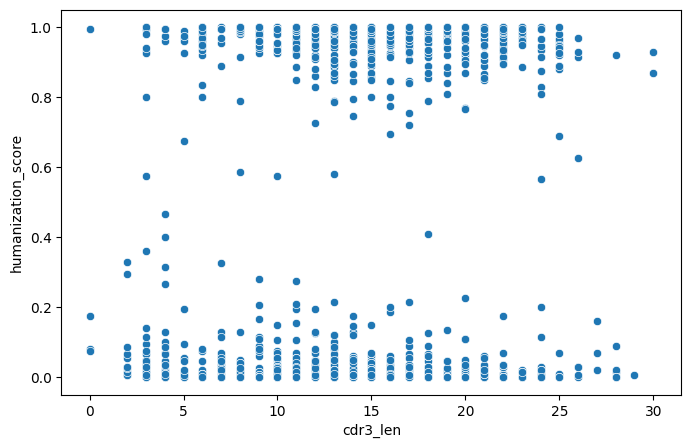

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=analysis_df,
    x="cdr3_len",
    y="humanization_score"
)

plt.show()

In [19]:
analysis_df["framework_len"] = (
    analysis_df["fr1_len"]
    + analysis_df["fr2_len"]
    + analysis_df["fr3_len"]
    + analysis_df["fr4_len"]
)

analysis_df["cdr_len"] = (
    analysis_df["cdr1_len"]
    + analysis_df["cdr2_len"]
    + analysis_df["cdr3_len"]
)

In [20]:
analysis_df[
    [
        "framework_len",
        "cdr_len",
        "humanization_score"
    ]
].corr()

,framework_len,cdr_len,humanization_score
framework_len,1.000000,0.062841,-0.712796
cdr_len,0.062841,1.000000,0.238916
humanization_score,-0.712796,0.238916,1.000000


In [21]:
analysis_df.to_csv(
    "cdr_framework_analysis.csv",
    index=False
)

##Framework-only vs CDR-only classifiers

In [22]:
analysis_df["cdr_sequence"] = (
    analysis_df["cdr1"]
    + analysis_df["cdr2"]
    + analysis_df["cdr3"]
)

analysis_df["framework_sequence"] = (
    analysis_df["fr1"]
    + analysis_df["fr2"]
    + analysis_df["fr3"]
    + analysis_df["fr4"]
)

In [23]:
analysis_df[
    ["cdr_sequence","framework_sequence"]
].head()

,cdr_sequence,framework_sequence
0,GFTFSRSAIVVGSGNTAATLRSLESDYYLDL,SVKVSCKASVQWVRQARGQCLEWIGWNYAQKLQERVTITRDMSTST...
1,GGSISSGGYYIYYSGSTARATKQWLAPWFDP,SETLSLTCTVSWSWIRQHPGKGLEWIGYYYNPSLKSRVTISVDTSK...
2,GDTRRSGCIYSGGSTTAISDTCAALHLGY,VQLVESGGGLVQPGGSLRLSCAASWAWFRQAPAEEREMVAYDYHAS...
3,GFTSFACSISPDGTTQSRCFRDGNWRLV,GSVQAGGSLRLSCTAPLDWYRQAEGNQREWVSAKLADSIKGRFTIS...
4,GFTFSSSDSSSGAVSLAASSAGGGWSLLTYKYNY,VQLVESGGGLVQPGGSLRLSCTASMSWGRQIPGKGLEWVSSLYADS...


In [24]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_features(seq):

    seq = str(seq)

    if len(seq) == 0:
        return {aa:0 for aa in AMINO_ACIDS}

    return {
        aa: seq.count(aa)/len(seq)
        for aa in AMINO_ACIDS
    }

In [25]:
X_full = pd.DataFrame(
    analysis_df["sequence"]
    .apply(aa_features)
    .tolist()
)

In [26]:
X_cdr = pd.DataFrame(
    analysis_df["cdr_sequence"]
    .apply(aa_features)
    .tolist()
)

In [27]:
X_framework = pd.DataFrame(
    analysis_df["framework_sequence"]
    .apply(aa_features)
    .tolist()
)

In [28]:
y = analysis_df["label"]

In [29]:
from sklearn.model_selection import train_test_split

Xf_train,Xf_test,y_train,y_test = train_test_split(
    X_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xc_train,Xc_test,_,_ = train_test_split(
    X_cdr,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xfr_train,Xfr_test,_,_ = train_test_split(
    X_framework,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [31]:
rf_full = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_full.fit(Xf_train,y_train)

pred_full = rf_full.predict(Xf_test)

acc_full = accuracy_score(
    y_test,
    pred_full
)

In [32]:
rf_cdr = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_cdr.fit(Xc_train,y_train)

pred_cdr = rf_cdr.predict(Xc_test)

acc_cdr = accuracy_score(
    y_test,
    pred_cdr
)

In [33]:
rf_framework = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_framework.fit(Xfr_train,y_train)

pred_framework = rf_framework.predict(Xfr_test)

acc_framework = accuracy_score(
    y_test,
    pred_framework
)

In [34]:
results = pd.DataFrame({
    "Model":[
        "Full Sequence",
        "CDR Only",
        "Framework Only"
    ],
    "Accuracy":[
        acc_full,
        acc_cdr,
        acc_framework
    ]
})

results

,Model,Accuracy
0,Full Sequence,0.9825
1,CDR Only,0.7950
2,Framework Only,0.9650


We can conclude:
Framework regions contain the majority of the humanization signal, while CDRs contribute substantially less.

## Feature Importance Analysis

In [35]:
importance_df = pd.DataFrame({
    "amino_acid": X_framework.columns,
    "importance": rf_framework.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,amino_acid,importance
18,W,0.214367
1,C,0.202485
5,G,0.086170
7,I,0.083238
3,E,0.074042
16,T,0.056865
12,P,0.046409
13,Q,0.045730
15,S,0.026030
10,M,0.023510


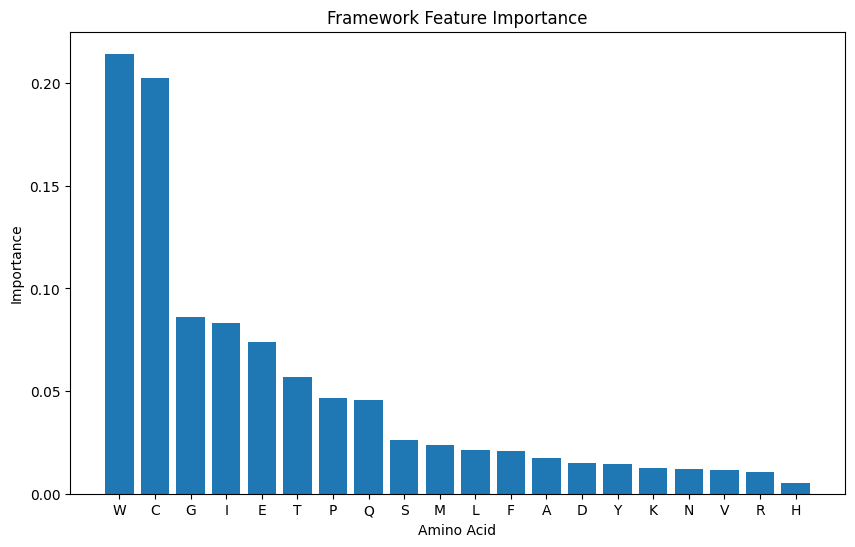

In [36]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,6))

plt.bar(
    top20["amino_acid"],
    top20["importance"]
)

plt.xlabel("Amino Acid")
plt.ylabel("Importance")
plt.title("Framework Feature Importance")

plt.show()

## FR1/FR2/FR3/FR4 experiment

In [49]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

def aa_features(seq):

    seq = str(seq)

    if len(seq) == 0:
        return {aa: 0 for aa in AMINO_ACIDS}

    return {
        aa: seq.count(aa) / len(seq)
        for aa in AMINO_ACIDS
    }

In [50]:
X_fr1 = pd.DataFrame(
    analysis_df["fr1"]
    .apply(aa_features)
    .tolist()
)
X_fr2 = pd.DataFrame(
    analysis_df["fr2"]
    .apply(aa_features)
    .tolist()
)
X_fr3 = pd.DataFrame(
    analysis_df["fr3"]
    .apply(aa_features)
    .tolist()
)
X_fr4 = pd.DataFrame(
    analysis_df["fr4"]
    .apply(aa_features)
    .tolist()
)

In [51]:
y = analysis_df["label"]

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def evaluate_region(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    return acc, model

In [53]:
acc_fr1, model_fr1 = evaluate_region(X_fr1, y)

acc_fr2, model_fr2 = evaluate_region(X_fr2, y)

acc_fr3, model_fr3 = evaluate_region(X_fr3, y)

acc_fr4, model_fr4 = evaluate_region(X_fr4, y)

In [54]:
region_results = pd.DataFrame({
    "Region": [
        "FR1",
        "FR2",
        "FR3",
        "FR4"
    ],
    "Accuracy": [
        acc_fr1,
        acc_fr2,
        acc_fr3,
        acc_fr4
    ]
})

region_results = region_results.sort_values(
    "Accuracy",
    ascending=False
)

region_results

,Region,Accuracy
0,FR1,0.9675
2,FR3,0.9400
3,FR4,0.9125
1,FR2,0.9100


FR1 alone almost matches the entire framework region (96.75% vs 96.50%) and nearly matches the full sequence model (98.25%).

## Position-Level Analysis in FR1

In [55]:
analysis_df["fr1_len"].describe()

,fr1_len
count,1999.000000
mean,16.145573
std,7.325844
min,0.000000
25%,10.000000
50%,11.000000
75%,25.000000
max,25.000000


In [57]:
import numpy as np

def split_positions(seq):
    # Handle NaN values explicitly, which are floats
    if pd.isna(seq):
        return []
    return list(str(seq))

fr1_matrix = analysis_df["fr1"].apply(
    split_positions
)

fr1_matrix = pd.DataFrame(
    fr1_matrix.tolist()
)

fr1_matrix.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,S,V,K,V,S,C,K,A,S,None,...,None,None,None,None,None,None,None,None,None,None
1,S,E,T,L,S,L,T,C,T,V,...,None,None,None,None,None,None,None,None,None,None
2,V,Q,L,V,E,S,G,G,G,L,...,S,L,R,L,S,C,A,A,S,None
3,G,S,V,Q,A,G,G,S,L,R,...,P,None,None,None,None,None,None,None,None,None
4,V,Q,L,V,E,S,G,G,G,L,...,S,L,R,L,S,C,T,A,S,None


In [58]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

X_pos = encoder.fit_transform(fr1_matrix)

In [59]:
rf_pos = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_pos.fit(X_pos, y)

RandomForestClassifier(n_estimators=300, random_state=42)

In [60]:
importance_df = pd.DataFrame({
    "position": fr1_matrix.columns,
    "importance": rf_pos.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,position,importance
19,19,0.186100
14,14,0.168411
20,20,0.137765
21,21,0.088827
12,12,0.071732
22,22,0.065520
15,15,0.053157
18,18,0.046748
16,16,0.042494
13,13,0.039476


In [62]:
analysis_df["fr1_len"].value_counts().sort_index()

,count
fr1_len,
0.0,15
3.0,1
4.0,7
5.0,2
6.0,2
7.0,7
8.0,9
9.0,446
10.0,246


In [65]:
(analysis_df["fr1_len"] == 0).sum()

np.int64(15)

In [64]:
analysis_df[
    ["fr1","cdr1","fr2","cdr2","fr3","cdr3","fr4"]
].head(20)

,fr1,cdr1,fr2,cdr2,fr3,cdr3,fr4
0,SVKVSCKAS,GFTFSRSA,VQWVRQARGQCLEWIGW,IVVGSGNT,NYAQKLQERVTITRDMSTSTAYLELNSLRSEDTAVYYC,AATLRSLESDYYLDL,WGRGTL
1,SETLSLTCTVS,GGSISSGGYY,WSWIRQHPGKGLEWIGY,IYYSGST,YYNPSLKSRVTISVDTSKNQFSLKLSSVTAADTAAYYC,ARATKQWLAPWFDP,WGQGTLVTVSS
2,VQLVESGGGLVQPGGSLRLSCAAS,GDTRRSGC,WAWFRQAPAEEREMVAY,IYSGGSTT,DYHASVKGRFTISRDTANTVYLRMNSLKFEDTAVYYC,AISDTCAALHLGY,WGQGTQVTVS
3,GSVQAGGSLRLSCTAP,GFTSFACS,LDWYRQAEGNQREWVSA,ISPDGTT,KLADSIKGRFTISQDKDKDTVYLQLNSATPEDTAMDSC,QSRCFRDGNWRLV,RGKGTQVTVS
4,VQLVESGGGLVQPGGSLRLSCTAS,GFTFSSSD,MSWGRQIPGKGLEWVSS,SSSGAVSL,LYADSVKGRFTISRDNAKNTVYLQMNSLKSEDTAMYYC,AASSAGGGWSLLTYKYNY,WGPGTQVTVS
5,EVQLVESGGGLVQPGRSLKLSCVAS,GFIFSNYW,MTWIRQAPGKGLEWVAS,ISSTGDNT,YYSDSVKGRFSLSRDNAKSTLYLQVNSLRSEDTATYYC,TSN,
6,ETLSLTCTVS,GGSISNYY,LNWIRQPPGKGLEWIGY,ISYIGST,SYNPSLKSRLTISVDTSKNQFSLKLTSVTAADTAFYYC,ASGEGSRYCSSTSCLDAFDI,WGQGTMVTVSS
7,EVQLVESGGGPVQPGRSLKLSCVAS,GFTFNNYW,MTWIRQAPGKGLEWVAS,ITNTGGST,YYPDSVKGRFTISRDNAKSTLYLQMDSLRSEDTATYYC,ARHGTTVVTSDY,WGQGVMVTVSS
8,EVQLVESGGGLVQPGGSLRLSCAAS,GFTFSSYY,MSWVRQAPGKGLEWVSA,ISWSGDST,NYADSVKGHFTISRDNARNTVSLQMNSLKSEDTALYYC,ATWSWVGSYFAF,WGAGTRLPV
9,SVKVSCKAS,GYTFTGYY,MHWVRQAPGQGLEWMGW,INPNSGGT,NYAQKFQGRVTMTRDTSISTAYMELSRLRSDDTAVYYC,ARAVKRITIFGVVITHNYYYYGMDV,WGQG


## Humanization Hotspots

In [71]:
top_positions = [19,14,20,21,12]

for pos in top_positions:

    print(f"\n===== Position {pos} =====")

    display(
        pd.crosstab(
            fr1_matrix[pos],
            analysis_df["species_clean"],
            normalize="columns"
        ).round(3)
    )


===== Position 19 =====


species_clean,camel,human,rat
19,,,
A,0.031,0.000,0.000
C,0.137,0.026,0.004
E,0.000,0.026,0.000
I,0.008,0.000,0.011
L,0.458,0.769,0.947
P,0.004,0.000,0.000
S,0.355,0.179,0.021
T,0.002,0.000,0.000
V,0.006,0.000,0.018



===== Position 14 =====


species_clean,camel,human,rat
14,,,
A,0.006,0.000,0.000
C,0.000,0.027,0.000
D,0.004,0.000,0.000
E,0.006,0.000,0.004
F,0.002,0.000,0.000
G,0.800,0.453,0.855
L,0.023,0.013,0.000
M,0.002,0.000,0.000
R,0.015,0.000,0.000



===== Position 20 =====


species_clean,camel,human,rat
20,,,
A,0.111,0.000,0.000
C,0.354,0.179,0.021
D,0.002,0.000,0.000
I,0.002,0.000,0.000
K,0.002,0.026,0.000
L,0.002,0.000,0.000
N,0.000,0.000,0.004
P,0.002,0.000,0.000
Q,0.002,0.000,0.000



===== Position 21 =====


species_clean,camel,human,rat
21,,,
A,0.342,0.128,0.018
C,0.476,0.744,0.975
E,0.012,0.000,0.000
F,0.000,0.026,0.000
G,0.010,0.000,0.000
K,0.002,0.000,0.000
L,0.004,0.026,0.000
N,0.000,0.026,0.000
Q,0.004,0.026,0.000



===== Position 12 =====


species_clean,camel,human,rat
12,,,
A,0.071,0.026,0.004
C,0.004,0.000,0.000
E,0.015,0.000,0.000
G,0.150,0.026,0.004
H,0.004,0.000,0.007
K,0.004,0.013,0.096
L,0.010,0.039,0.000
N,0.002,0.000,0.000
P,0.251,0.065,0.018
